# 04 — Frozen Lake + Exploration
**Week 3 | RL Fundamentals**

First contact with **Gymnasium**. We run various policies on Frozen Lake and measure performance — no learning yet, just understanding the environment and the exploration-exploitation trade-off.

In [2]:
# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
print('Gymnasium version:', gym.__version__)

Gymnasium version: 1.3.0


In [3]:
env = gym.make('FrozenLake-v1', is_slippery=False)
print(f"Observation space: {env.observation_space}  ({env.observation_space.n} states)")
print(f"Action space:      {env.action_space}  (0=L, 1=D, 2=R, 3=U)")
print(f"\nTransition model for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.unwrapped.P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

Observation space: Discrete(16)  (16 states)
Action space:      Discrete(4)  (0=L, 1=D, 2=R, 3=U)

Transition model for state 0, action 1 (DOWN):
  P=1.00 -> state 4, reward=0, done=False


## 1. Random Policy Baseline

In [4]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200):
    wins = 0
    returns = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0
        for _ in range(max_steps):
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                if r == 1.0: wins += 1
                break
        returns.append(ep_return)
    return wins / n_episodes, np.mean(returns)

random_win, random_ret = evaluate_policy(env, lambda s: env.action_space.sample())
print(f"Random policy:  win rate={random_win:.2%}, avg return={random_ret:.4f}")

Random policy:  win rate=0.80%, avg return=0.0080


## 2. Fixed Directional Policy
Manually specify the best deterministic path.

In [5]:
# Hand-crafted policy for 4x4 non-slippery FrozenLake (actions: 0=L,1=D,2=R,3=U)
# Map: SFFF / FHFH / FFFH / HFFG
hand_policy = [
    1, 2, 1, 0,   # row 0
    1, 0, 1, 0,   # row 1 (H at pos 5,7)
    2, 2, 1, 0,   # row 2
    0, 2, 2, 0,   # row 3 (H at pos 12, G at 15)
]
hand_win, hand_ret = evaluate_policy(env, lambda s: hand_policy[s])
print(f"Hand policy:    win rate={hand_win:.2%}, avg return={hand_ret:.4f}")

Hand policy:    win rate=100.00%, avg return=1.0000


## 3. ε-greedy Policy with Learned Bias
Start with a 'smart' action bias and add exploration noise.

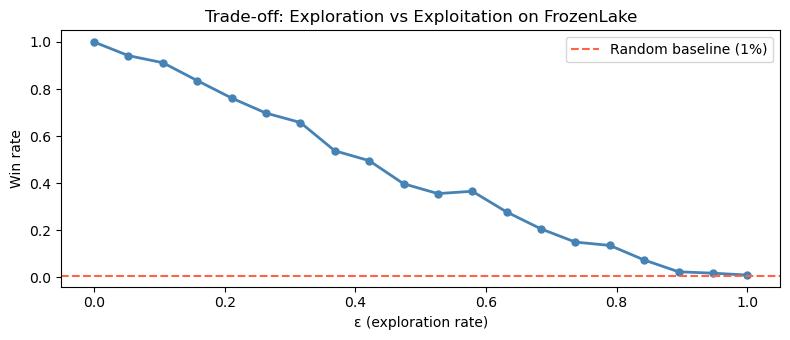

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
eps_values = np.linspace(0, 1, 20)
results = []
for eps in eps_values:
    def eps_hand(s, eps=eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return hand_policy[s]
    w, _ = evaluate_policy(env, eps_hand, n_episodes=500)
    results.append(w)
ax.plot(eps_values, results, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.axhline(random_win, color='tomato', linestyle='--', label=f'Random baseline ({random_win:.0%})')
ax.set_xlabel('ε (exploration rate)'); ax.set_ylabel('Win rate')
ax.set_title('Trade-off: Exploration vs Exploitation on FrozenLake')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Inspect the MDP Transitions

In [7]:
# Show how slippery=True changes things
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
slip_win, _ = evaluate_policy(env_slip, lambda s: hand_policy[s])
print(f"Hand policy on SLIPPERY lake: win rate={slip_win:.2%}")
print("\n(Our deterministic policy fails on a stochastic environment!)")

Hand policy on SLIPPERY lake: win rate=3.30%

(Our deterministic policy fails on a stochastic environment!)


## ✅ Exercises
1. Try the 8×8 FrozenLake map (`map_name='8x8'`). Does the hand-crafted policy still work? Why not?
2. Plot win rate vs number of evaluation episodes for the random policy. How many episodes do you need for a stable estimate?
3. **Challenge**: write a systematic policy for the slippery lake — one that avoids dangerous edges. Test it.

Ans 1) No, Reason in output

In [8]:
env8	=	gym.make('FrozenLake-v1',	map_name='8x8',	is_slippery=False)
print(f"States:	{env8.observation_space.n}")			#	64
try:
				w,	_	=	evaluate_policy(env8,	lambda	s:	hand_policy[s])
				print(f"Hand	policy	on	8x8:	{w:.2%}")
except	IndexError	as	e:
				print("IndexError	—	hand_policy	has	only	16	entries,	8x8	has	64	states")


States:	64
IndexError	—	hand_policy	has	only	16	entries,	8x8	has	64	states


Ans 2)  As shown below - Error	bars	shrink	as	~1/√n	(Monte	Carlo	standard
error).	With	the	random	policy’s	win	rate	around	1–2%,	estimates
below	~500	episodes	are	junk	—	a	50-episode	run	will	often	report
0%.	Roughly	1000–1500	episodes	gives	a	stable	estimate

C:\Users\arinu\AppData\Local\Temp\ipykernel_38092\1650080191.py:17: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout();	plt.show()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


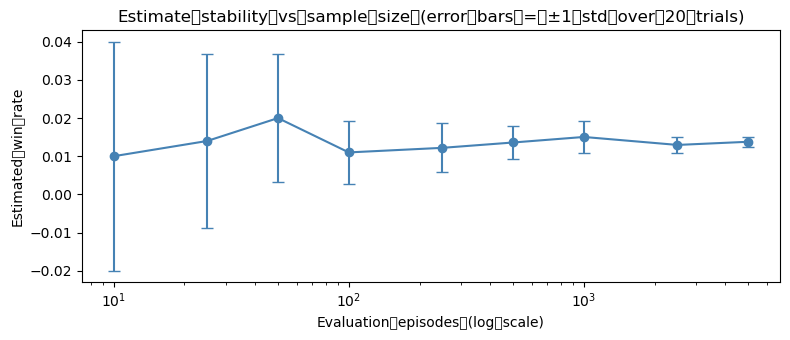

n=   10:	std	of	estimate	=	0.0300
n=   25:	std	of	estimate	=	0.0229
n=   50:	std	of	estimate	=	0.0167
n=  100:	std	of	estimate	=	0.0083
n=  250:	std	of	estimate	=	0.0064
n=  500:	std	of	estimate	=	0.0042
n= 1000:	std	of	estimate	=	0.0041
n= 2500:	std	of	estimate	=	0.0022
n= 5000:	std	of	estimate	=	0.0014


In [9]:
episode_counts	=	[10,	25,	50,	100,	250,	500,	1000,	2500,	5000]
n_trials	=	20			#	repeat	each	estimate	to	see	its	spread
means,	stds	=	[],	[]
for	n	in	episode_counts:
				estimates	=	[evaluate_policy(env,	lambda	s:	
env.action_space.sample(),
																																	n_episodes=n)[0]	for	_	in	
range(n_trials)]
				means.append(np.mean(estimates))
				stds.append(np.std(estimates))
plt.figure(figsize=(8,	3.5))
plt.errorbar(episode_counts,	means,	yerr=stds,	color='steelblue',
													marker='o',	capsize=4,	linewidth=1.5)
plt.xscale('log')
plt.xlabel('Evaluation	episodes	(log	scale)');	plt.ylabel('Estimated	win	rate')
plt.title('Estimate	stability	vs	sample	size	(error	bars	=	±1	std	over	20	trials)')
plt.tight_layout();	plt.show()
for	n,	s	in	zip(episode_counts,	stds):
				print(f"n={n:>5}:	std	of	estimate	=	{s:.4f}")

Ans 3) My Observations - true	optimum	for	slippery	4×4	(~74%,	you’ll	confirm	with	value
iteration	in	Week	4).	The	counterintuitive	part:	the	optimal	action
often	points	away	from	the	goal,	because	what	matters	is	where	the	2
out-of-3	slip	outcomes	land,	not	the	intended	direction.

In [10]:
safe_policy	=	[
0,	3,	3,	3,			#	row	0:	hug	the	left	wall	/	push	up	(up-slips	bounce	off	wall)
0,	0,	0,	0,			#	row	1:	LEFT	everywhere	—	perpendicular	slips	are	U/D,	never	into	5	or	7	from	the	safe	column
3,	1,	0,	0,			#	row	2
0,	2,	1,	0,			#	row	3:	work	along	the	bottom	toward	G
]
slip_win_safe,	_	=	evaluate_policy(env_slip,	lambda	s:	
safe_policy[s],	n_episodes=5000)
print(f"Hand	policy	on	slippery	lake:		{slip_win:.2%}")
print(f"Safe	policy	on	slippery	lake:		{slip_win_safe:.2%}")

Hand	policy	on	slippery	lake:		3.30%
Safe	policy	on	slippery	lake:		74.18%
